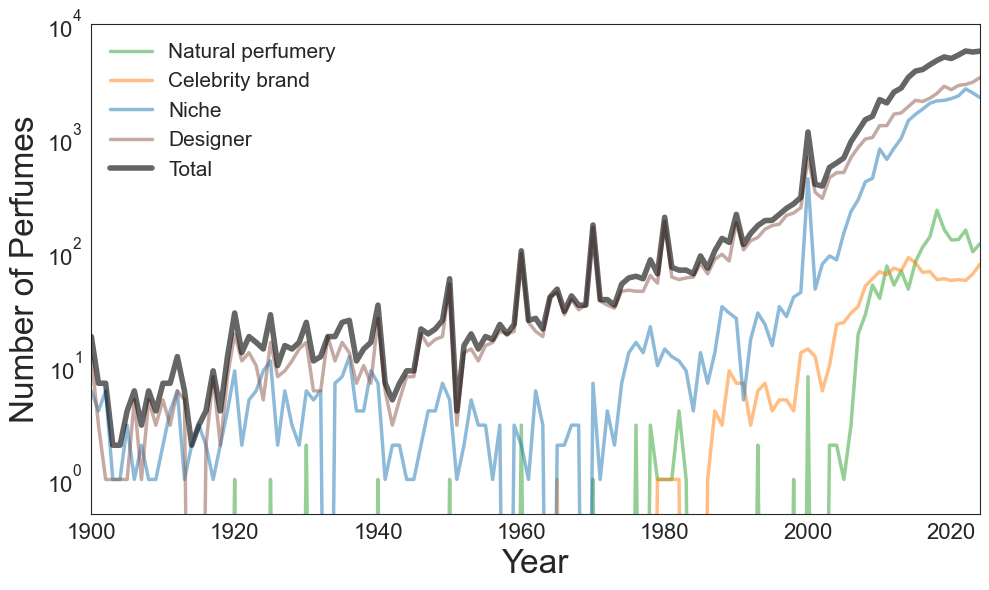

In [1]:
import os
import sys
import ast
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import seaborn as sns
sys.path.append(os.path.abspath(".."))
from utils.utils import *
from pathlib import Path


#load data for the whole notebook
file_path = "../dataset/perfume_dataset.csv"
data = pd.read_csv(file_path)

data['year'] = pd.to_numeric(data['year'], errors='coerce')
data = data.dropna(subset=['year'])

# Filter for years between 1900 and 2024
data = data[(data['year'] >= 1900) & (data['year'] <= 2024)]
data['year'] = data['year'].astype(int)

#process data
data['Type'] = data['Type'].fillna('')
data.loc[data['Type'].str.strip() == '', 'Type'] = 'Designer'

data_exploded = data.assign(Type=data['Type'].str.split('|')).explode('Type')
data_exploded['Type'] = data_exploded['Type'].str.strip()

type_counts = (
    data_exploded
    .groupby(['year','Type'])
    .size()
    .reset_index(name='count')
)

df_by_type = type_counts.pivot(index='year', columns='Type', values='count').fillna(0)


df_total = data.groupby('year').size().rename('Total')
df_combined = df_by_type.join(df_total, how='outer').fillna(0)
df_combined = df_combined.sort_index()
df_combined = df_combined.rename(columns={"Niche designer": "Niche"})

#costum order and colors
desired_order = [
    "Natural perfumery", 
    "Celebrity brand", 
    "Niche", 
    "Designer", 
    "Total"
]

color_map = {
    "Natural perfumery": "#2ca02c",   # green
    "Celebrity brand":   "#ff7f0e",   # orange
    "Niche":             "#1f77b4",   # blue
    "Designer":          "#8c564b",   # brown
    "Total":             "black"
}

final_cols = [col for col in desired_order if col in df_combined.columns]

#plot
sns.set_style('white')
plt.figure(figsize=(10, 6))

for col in final_cols:
    if col == 'Total':
        plt.plot(
            df_combined.index, df_combined[col],
            label=col,
            color=color_map[col],
            linewidth=4,
            linestyle='-',
            alpha=0.6,
            zorder=10
        )
    else:
        plt.plot(
            df_combined.index, df_combined[col],
            label=col,
            color=color_map[col],
            linewidth=2.5,
            alpha=0.5
        )

plt.yscale('symlog', linthresh=0.0001)  
plt.ylim(0.5, 10000)
plt.xlim(1900, 2024)
plt.xlabel('Year', fontsize=24)
plt.ylabel('Number of Perfumes', fontsize=24)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(title='', bbox_to_anchor=(0, 1), loc='upper left', frameon=False,fontsize=15)
plt.tight_layout()
plt.savefig("../output/Figure_1b.svg", format="svg", dpi=300)
plt.show()


Unique houses: 5462
Unique perfumers: 2483

 Top 10 Perfumers
1. Alberto Morillas: 502 perfumes
2. Olivier Cresp: 410 perfumes
3. Dominique Ropion: 375 perfumes
4. Bertrand Duchaufour: 360 perfumes
5. Verônica Kato: 358 perfumes
6. Nathalie Lorson: 315 perfumes
7. Christian Provenzano: 301 perfumes
8. Dawn Spencer Hurwitz: 300 perfumes
9. Chris Maurice: 264 perfumes
10. Sharra Lamoureaux: 260 perfumes

 Top 10 Houses
1. The Dua Brand: 1618 perfumes
2. Avon: 1065 perfumes
3. Zara: 855 perfumes
4. Victoria s Secret: 761 perfumes
5. Bath Body Works: 604 perfumes
6. O Boticario: 553 perfumes
7. Jequiti: 538 perfumes
8. Guerlain: 537 perfumes
9. Natura: 486 perfumes
10. Oriflame: 379 perfumes


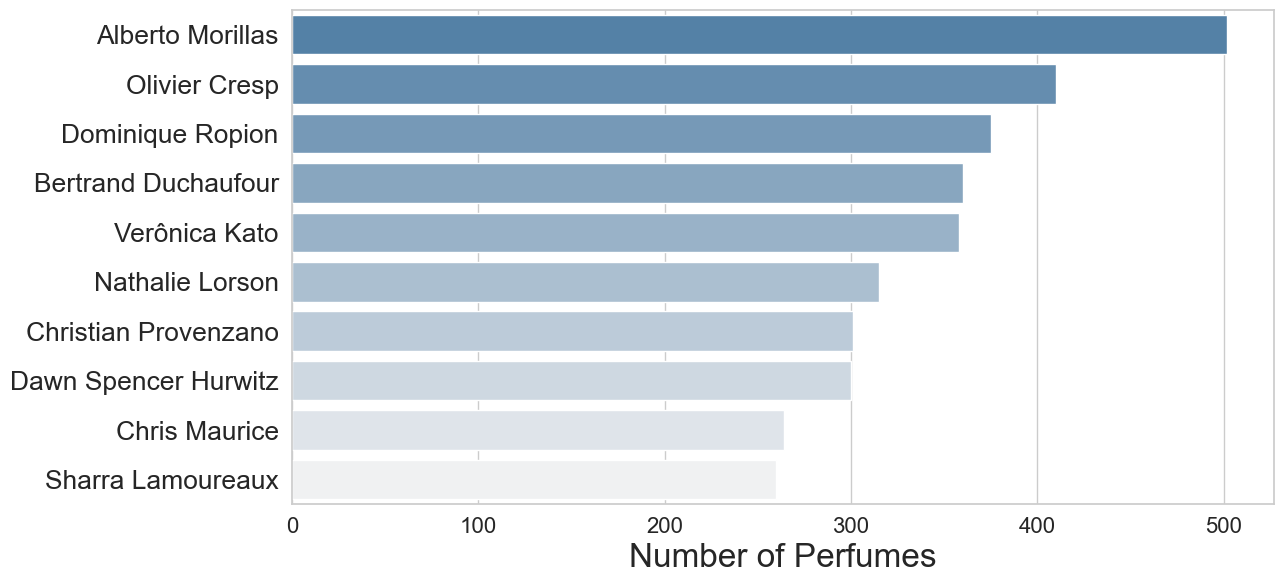

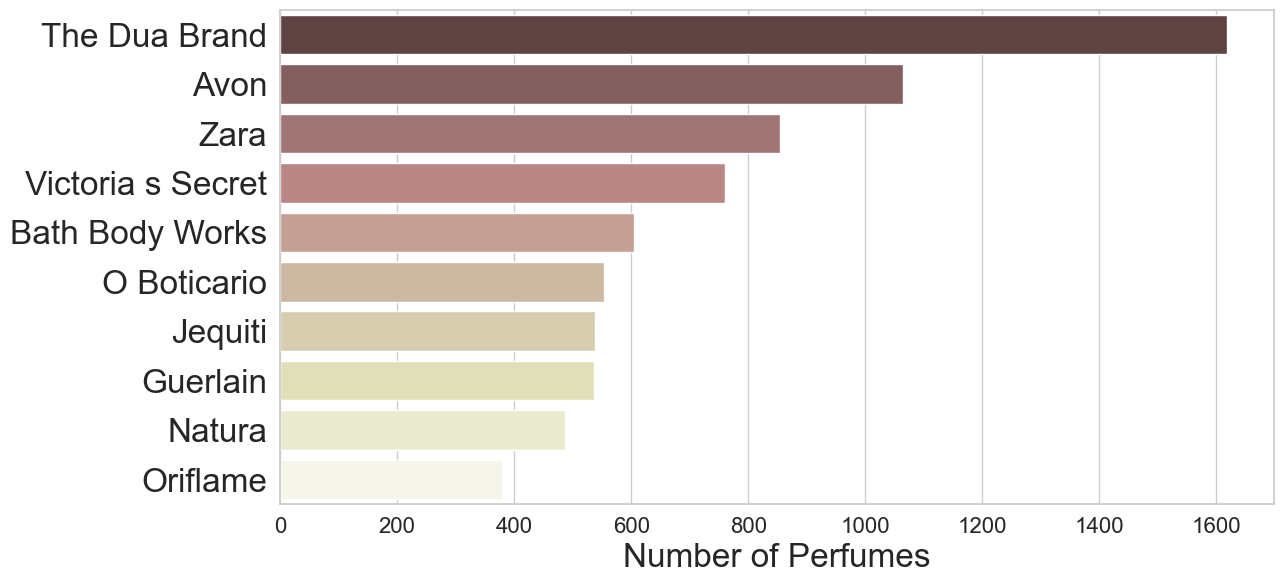

In [2]:
file_path = "../dataset/perfume_dataset.csv"  
data = pd.read_csv(file_path)
# parse perfumer and house column
data['perfumer'] = data['perfumer'].apply(parse_perfumer)
data['house'] = data['house'].fillna("").apply(lambda x: x.strip())

perfumer_exploded = data.explode('perfumer')

#count the occurrences of each perfumer and house and select the top 10
perfumer_counts = perfumer_exploded['perfumer'].value_counts().head(10)
house_counts = data['house'].value_counts().head(10)
print("Unique houses:", len(data['house'].unique()))
print("Unique perfumers:", len(perfumer_exploded['perfumer'].unique()))

print("\n Top 10 Perfumers")
for i, (name, count) in enumerate(perfumer_counts.items(), start=1):
    print(f"{i}. {name}: {count} perfumes")

print("\n Top 10 Houses")
for i, (name, count) in enumerate(house_counts.items(), start=1):
    print(f"{i}. {name}: {count} perfumes")

sns.set_theme(style="whitegrid")
# df_perf = perfumer_counts.rename_axis("Perfumer").reset_index(name="NumPerfumes")

# plot top 10 perfumers
plt.figure(figsize=(13, 6))
palette_perfumer = sns.light_palette("steelblue", len(perfumer_counts),reverse=True)
sns.barplot(x=perfumer_counts.values, y=perfumer_counts.index,hue=perfumer_counts.index, palette=palette_perfumer,legend=False)
plt.xlabel('Number of Perfumes', fontsize=24)
plt.ylabel('', fontsize=1)
plt.xticks(fontsize=16)
plt.yticks(fontsize=19)
plt.tight_layout()
plt.savefig("../output/Figure_1c.svg", format="svg", dpi=300)
plt.show()

# plot top 10 houses
plt.figure(figsize=(13, 6))
palette_house = sns.color_palette("pink", len(house_counts))
sns.barplot(x=house_counts.values, y=house_counts.index,hue=house_counts.index, palette=palette_house,legend=False)
plt.xlabel('Number of Perfumes', fontsize=24)
plt.ylabel('', fontsize=1)
plt.xticks(fontsize=16)
plt.yticks(fontsize=24)
plt.tight_layout()
plt.savefig("../output/Figure_1d.svg", format="svg", dpi=300)
plt.show()

/var/folders/ts/n9fbfxkj091_fpcsbsgj4zcxb6n5sd/T/ipykernel_47586/4003881804.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_accords))


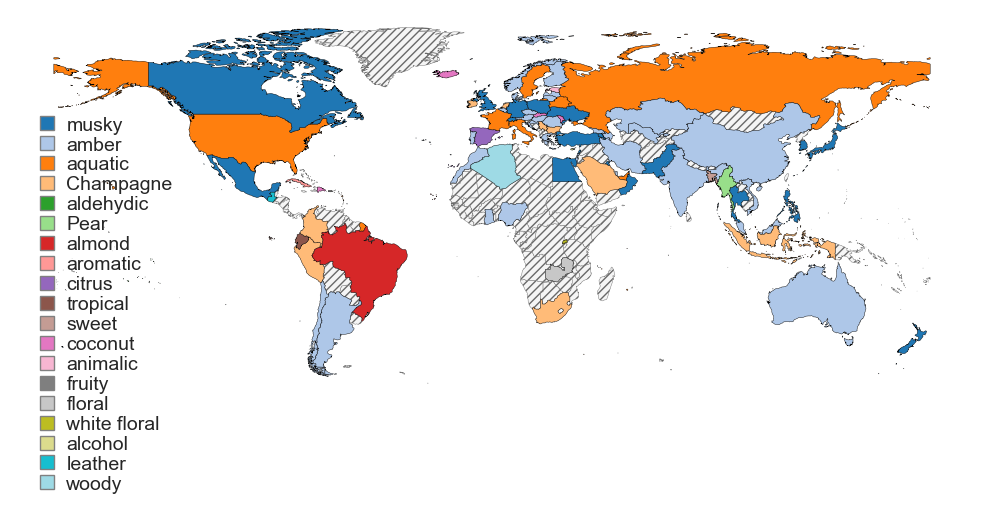

In [3]:
#standardize country names
country_name_mapping = {
    "United States": "United States of America",
    "St. Barts": "St-Barthélemy",
    "United kingdom": "United Kingdom",
    "Dubai": "United Arab Emirates",
    "Moldavia": "Moldova",
    "Tenerife": "Spain",
    "Dominican Republic": "Dominican Rep.",
    "Czech Republic": "Czechia",
    "Tahiti": "Fr. Polynesia",
    "Wales": "United Kingdom",
}
data["Country"] = data["Country"].replace(country_name_mapping)


#take the top accord per perfume
flat_rows = []
for _, row in data.iterrows():
    country = row['Country']
    try:
        accords_dict = json.loads(row['accords'])
        if isinstance(accords_dict, dict):
            top_accords = sorted(accords_dict.items(), key=lambda x: x[1], reverse=True)[:1]
            for accord_name, accord_value in top_accords:
                flat_rows.append({
                    'Country': country,
                    'accord': accord_name,
                    'value': accord_value
                })
    except (json.JSONDecodeError, TypeError):
        continue

data_flat = pd.DataFrame(flat_rows)
# mean value per (Country, accord) → pick dominant accord
grouped = (data_flat.groupby(["Country", "accord"], as_index=False)["value"]
                  .mean()
                  .rename(columns={"value": "mean_value"}))
dominant = (grouped.sort_values(["Country", "mean_value"], ascending=[True, False])
                    .drop_duplicates(subset="Country")
                    .rename(columns={"accord": "dominant_accord_mean"})
                    .set_index("Country"))

#load world shapefile
world = (gpd.read_file("../utils/ne_50m_admin_0_countries.shp")
           .query("NAME != 'Antarctica'")
           .explode(index_parts=False)
           .reset_index(drop=True)
           .loc[lambda g: g.is_valid])

map_data = world.merge(dominant[["dominant_accord_mean"]],
                       left_on="NAME", right_index=True, how="left")

accord_counts = map_data["dominant_accord_mean"].value_counts()
accord_order  = accord_counts.index
map_data["dominant_accord_mean"] = map_data["dominant_accord_mean"].astype(
    pd.CategoricalDtype(categories=accord_order, ordered=True)
)

#plot
fig, ax = plt.subplots(figsize=(10, 15))

# missing countries
missing = map_data[map_data["dominant_accord_mean"].isna()]
if not missing.empty:
    missing.plot(ax=ax,
                 facecolor="whitesmoke",
                 edgecolor="dimgray",   
                 hatch="////",
                 linewidth=0.3,
                 zorder=1)

#present countries
present = map_data.dropna(subset=["dominant_accord_mean"])
present.plot(column="dominant_accord_mean",
             cmap="tab20",
             ax=ax,
             edgecolor="black",
             linewidth=0.3,
             legend=False,
             zorder=2)

unique_accords = present["dominant_accord_mean"].unique()
cmap = plt.cm.get_cmap("tab20", len(unique_accords))
handles = [mlines.Line2D([], [], marker='s', markersize=10,
                         color='none', markerfacecolor=cmap(i),
                         markeredgecolor='gray', label=str(a))
           for i, a in enumerate(unique_accords)]
plt.legend(handles=handles,
           loc="lower left",
           bbox_to_anchor=(0.0, -0.28),
           fontsize=14,
           frameon=False,
           labelspacing=0.1,
           handletextpad=0.0)

ax.set_axis_off()
plt.tight_layout()
plt.savefig("../output/Figure_1e.svg", format="svg", dpi=300)
plt.show()

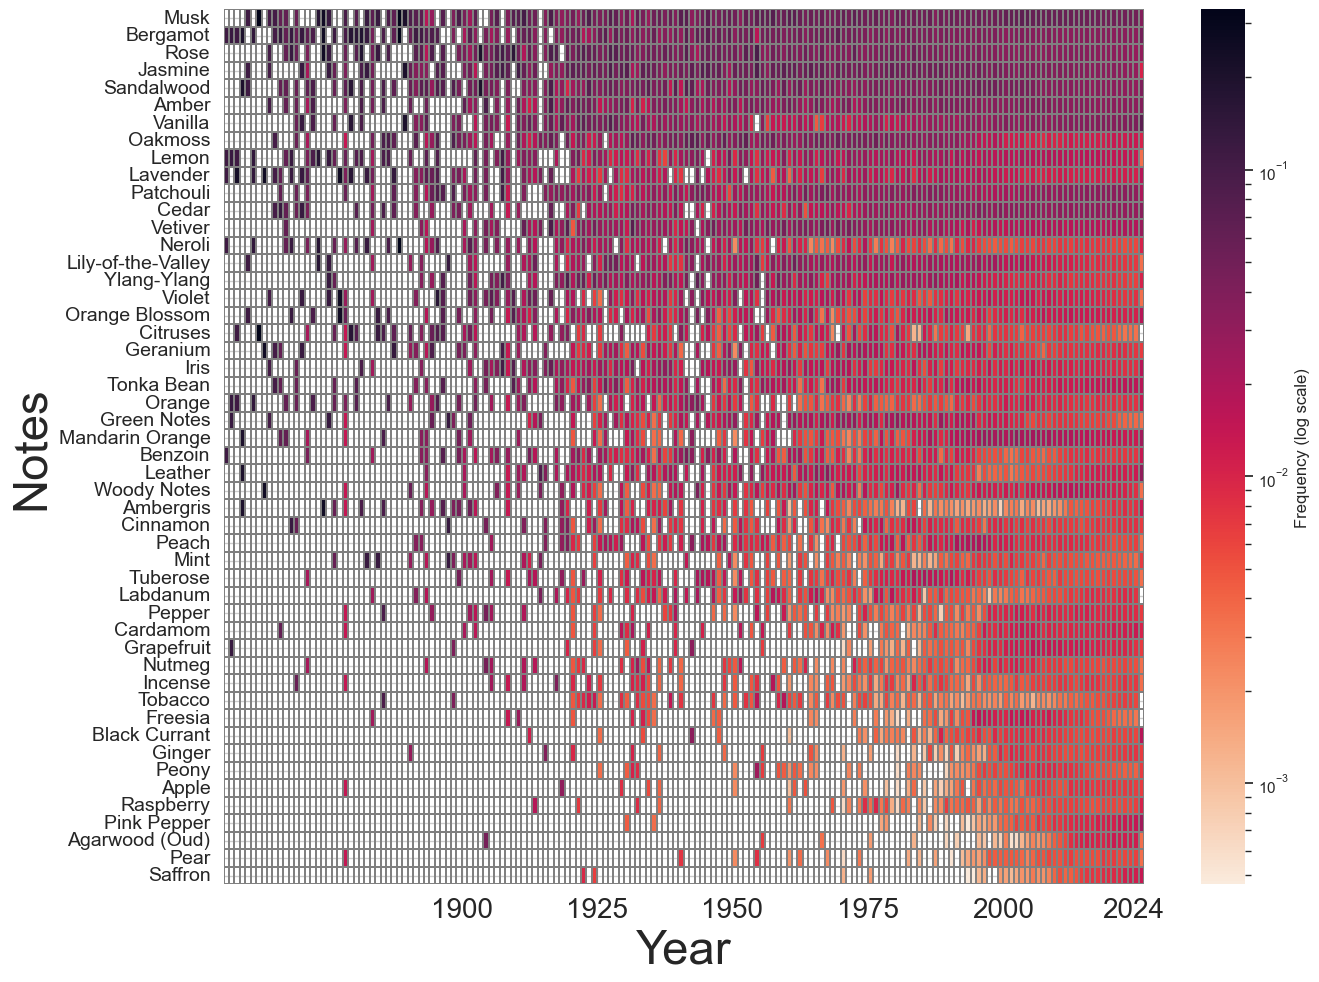

In [4]:
data['note_list'] = data['notes'].apply(parse_notes)

rows = [{'year': row.year, 'note': n}
        for _, row in data.iterrows()
        for n in row.note_list]

exploded = pd.DataFrame(rows)

#count notes and normalize
note_counts = exploded.groupby(['year', 'note']).size().reset_index(name='count')
note_counts['percentage'] = note_counts['count'] / note_counts.groupby('year')['count'].transform('sum')

#keep top‑50 notes
top_notes = (note_counts.groupby('note')['count']
                       .sum()
                       .nlargest(50)
                       .index)
filtered = note_counts[note_counts['note'].isin(top_notes)]
pivot = (filtered.pivot(index='note', columns='year', values='percentage')
                   .fillna(0))
pivot['total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('total', ascending=False).drop(columns='total')

desired_years = [1900, 1925, 1950, 1975, 2000, 2024]
for y in desired_years:
    if y not in pivot.columns:
        pivot[y] = 0
pivot = pivot.reindex(sorted(pivot.columns), axis=1)
year_positions = [i for i, y in enumerate(pivot.columns) if y in desired_years]

#plot
plt.figure(figsize=(14, 10))
sns.heatmap(
    pivot,
    cmap='rocket_r',
    norm=mcolors.LogNorm(vmin=pivot.replace(0, float('nan')).min().min(),
                         vmax=pivot.max().max()),
    cbar_kws={'label': 'Frequency (log scale)'},
    linewidths=0.05,
    linecolor='gray',
    yticklabels=pivot.index 
)

plt.xlabel('Year', fontsize=34)
plt.ylabel('Notes', fontsize=34)
plt.xticks(ticks=year_positions, labels=desired_years, rotation=0, fontsize=20)
plt.yticks(rotation=0, fontsize=14)
plt.tight_layout()
plt.savefig("../output/Figure_1f.svg", format="svg", dpi=300)
plt.show()


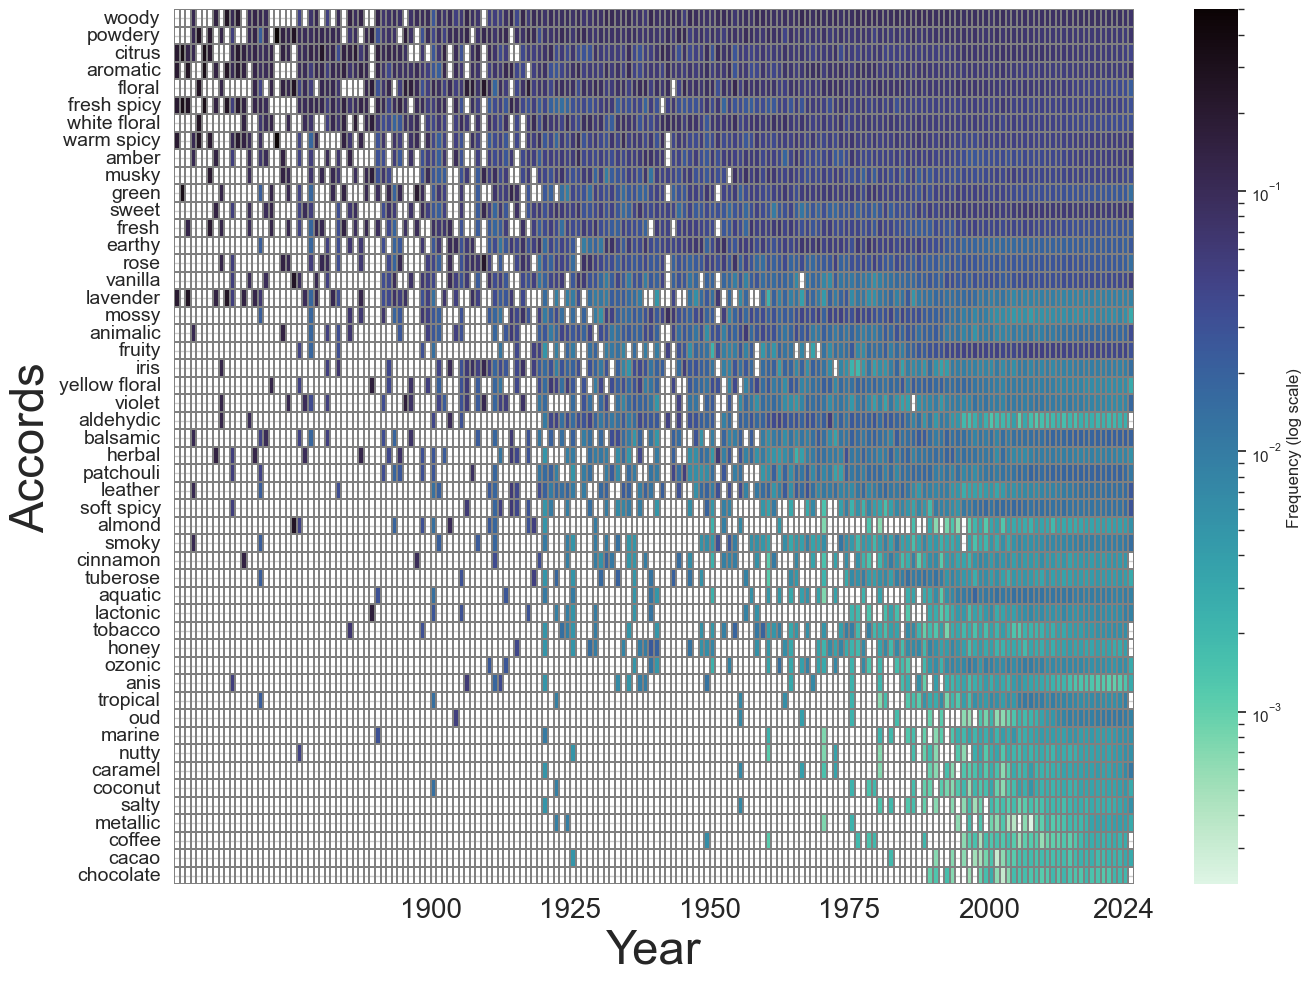

In [5]:
data['accord_list'] = data['accords'].apply(parse_accords)

rows = [{'year': row.year, 'accord': acc}
        for _, row in data.iterrows()
        for acc in row.accord_list]

exploded = pd.DataFrame(rows)

#count accords and normalise
acc_counts = exploded.groupby(['year', 'accord']).size().reset_index(name='count')
acc_counts['percentage'] = acc_counts['count'] / acc_counts.groupby('year')['count'].transform('sum')

#keep top‑50 accords
top_acc = (acc_counts.groupby('accord')['count']
                      .sum()
                      .nlargest(50)
                      .index)
filtered = acc_counts[acc_counts['accord'].isin(top_acc)]
pivot = (filtered.pivot(index='accord', columns='year', values='percentage')
                   .fillna(0))
pivot['total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('total', ascending=False).drop(columns='total')

desired_years = [1900, 1925, 1950, 1975, 2000, 2024]
for y in desired_years:
    if y not in pivot.columns:
        pivot[y] = 0
pivot = pivot.reindex(sorted(pivot.columns), axis=1)
year_positions = [i for i, y in enumerate(pivot.columns) if y in desired_years]

#plot
plt.figure(figsize=(14, 10))
sns.heatmap(
    pivot,
    cmap='mako_r',
    norm=mcolors.LogNorm(vmin=pivot.replace(0, float('nan')).min().min(),
                         vmax=pivot.max().max()),
    cbar_kws={'label': 'Frequency (log scale)'},
    linewidths=0.05,
    linecolor='gray',
    yticklabels=pivot.index 
)

plt.xlabel('Year', fontsize=34)
plt.ylabel('Accords', fontsize=34)
plt.xticks(ticks=year_positions, labels=desired_years, rotation=0, fontsize=20)
plt.yticks(rotation=0, fontsize=14)
plt.tight_layout()
plt.savefig("../output/Figure_1g.svg", format="svg", dpi=300)
plt.show()

In [6]:
print(exploded.columns.tolist())
print(exploded.head())


['year', 'accord']
     year      accord
0  2022.0       woody
1  2022.0       amber
2  2022.0  warm spicy
3  2022.0     vanilla
4  2022.0     powdery


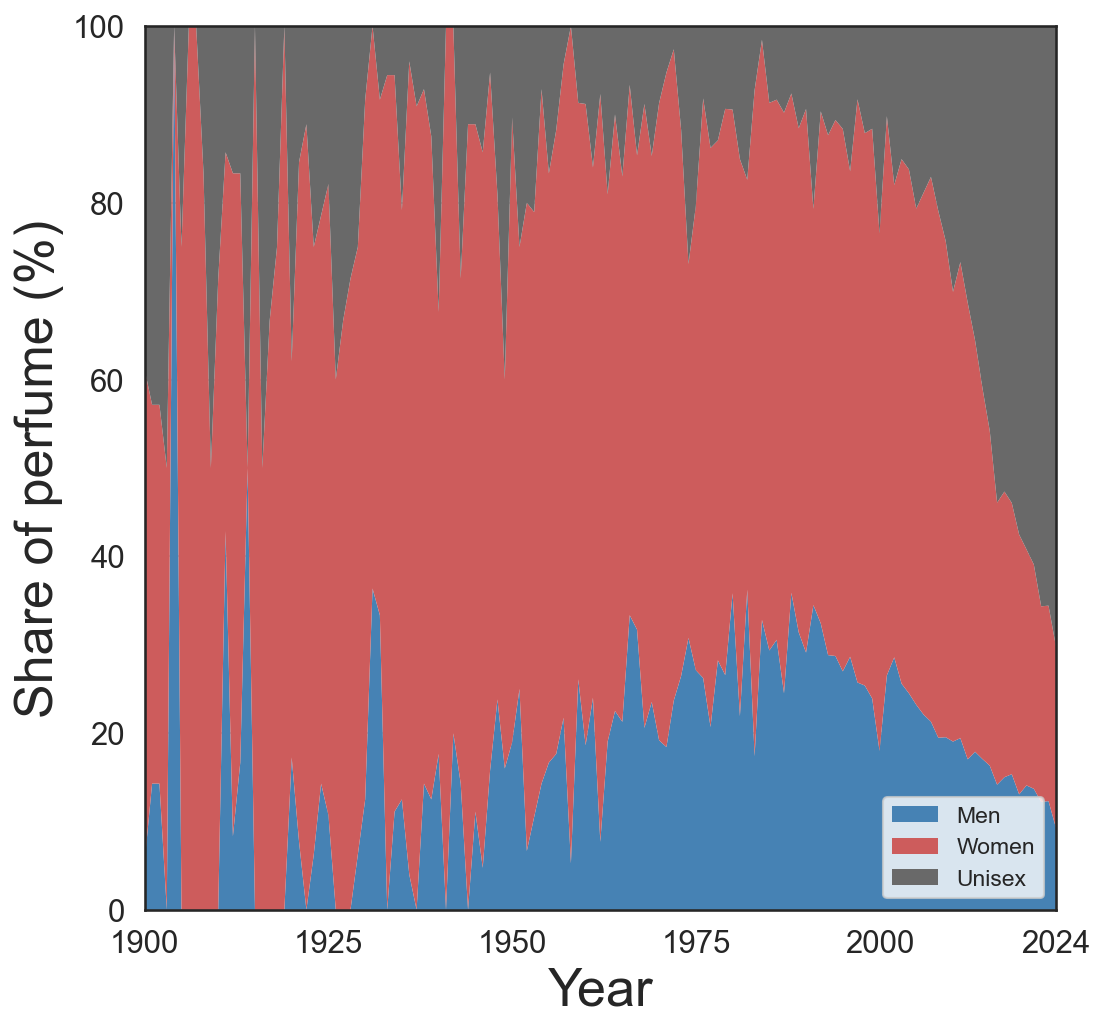

In [7]:
MIN_YEAR, MAX_YEAR = 1900, 2024
TICKS         = [1900, 1925, 1950, 1975, 2000, 2024]

#standardize gender catagories
label_map = {
    "male":   "Men",    "men": "Men",    "m": "Men",
    "female": "Women",  "women": "Women","f": "Women",
    "unisex": "Unisex", "shared": "Unisex",
}
data["gender_std"] = (
    data["gender"].str.lower().map(label_map).fillna(data["gender"])
)

#count and calculate percentage
counts = (data.groupby(["year", "gender_std"]).size().reset_index(name="count"))

counts["percentage"] = (
    counts["count"] /
    counts.groupby("year")["count"].transform("sum")
) * 100

years   = counts["year"].unique()
genders = ["Men", "Women", "Unisex"]

counts = (counts.set_index(["year", "gender_std"])
                 .reindex(pd.MultiIndex.from_product([years, genders],
                                                     names=["year", "gender_std"]),
                          fill_value=0)
                 .reset_index())

pivot = (counts.pivot(index="year",
                      columns="gender_std",
                      values="percentage")
               .fillna(0)
               .sort_index())

#stacked area plot
sns.set_style("whitegrid", {"axes.edgecolor": "0.15"})
plt.rcParams.update({
    "figure.dpi":     150,
    "savefig.dpi":    300,
    "font.size":      11,
    "axes.titlesize": 13,
    "axes.labelsize": 25,
    "xtick.labelsize":15,
    "ytick.labelsize":15,
    "legend.fontsize":11,
    "lines.antialiased": True,
})

palette = {
    "Men":    "steelblue",  # blue
    "Women":  "indianred",  # red
    "Unisex": "dimgray",  # purple
}


fig, ax = plt.subplots(figsize=(7.5, 7))
pivot[genders].plot.area(
    stacked=True,
    linewidth=0,
    color=[palette[g] for g in genders],
    ax=ax,
)

ax.set_ylim(0, 100)
ax.set_xlim(MIN_YEAR, MAX_YEAR)
ax.set_ylabel("Share of perfume (%)")
ax.set_xlabel("Year")
ax.set_xticks(TICKS)
ax.set_xticklabels(TICKS, rotation=0)
ax.legend(title="", frameon=True, loc="lower right")
plt.tight_layout()
plt.tight_layout()
plt.savefig("../output/Figure_1h.svg", format="svg", dpi=300)
plt.show()

